# RG3 2차 시도 — 선행 논문 기반 파생 변수로 재평가 (계획 4단계)

**지금까지 (보고서 1~3단계)**
- 1단계: `RG33.ipynb`(데이터 진단·정제·이상탐지)와 `RG33_models.ipynb`(36종 모델 비교)에서 공정 값 23개로 이상탐지·지도학습을 샷 묶음 교차검증으로 비교했다.
- 2단계 판정 **실패**: RG3: 최고 XGBoost 0.096 ± 0.061로 무작위(0.072)와의 차이가 fold 간 표준편차 안. 샷 순서 대비 공정 값의 추가 기여도 유의하지 않음(조건부 순열 LightGBM p = 0.35). 튜닝·앙상블·불균형 샘플링도 효과가 없어, 원인을 **모델이 아니라 입력 정보 부족**으로 판단했다.
- 3단계: 신규 데이터(원본 1차 가공 데이터의 제품명·시각)는 확보하지 못해, **기존 23개 공정 값으로 만들 수 있는 파생 변수**를 선행 논문을 참고해 설계했다 (보고서 표 5).

**이 노트북 (4단계)**: 1차와 **같은 분할·지표·기준선**으로, 1차 상위 계열(부스팅·랜덤포레스트)과 해석용 로지스틱을 `공정 값 23 + 파생 변수`로 다시 학습해 판정한다.

**성공 기준 (재시도 전 확정, 보고서 4단계)** — 판정용 평가 **E2 앞쪽 부품 안** (`pair_pos = 0`, 591부품 · 불량 23)에서
1. PR-AUC가 기준선과 1차 최고 모델을 **fold 간 표준편차 이상** 넘을 것. 기준선 = **무작위** (0.072 ± 0.057, 샷 순서 0.046은 무작위보다 낮음), 1차 최고 = **XGBoost (공정 값)** (0.096 ± 0.061)
2. 파생 변수의 추가 기여가 **조건부 순열검정 p < 0.05**일 것

| 섹션 | 내용 | 보고서 연결 |
|---|---|---|
| 1 | 설정·데이터 (1차와 같은 `model_zoo.py`) | — |
| 2 | 파생 변수 만들기 + 누수 점검 | 3단계 표 5 |
| 3 | 파생 변수 탐색: 불량 vs 양품, 시간 흐름과의 관계 | 제3장 영향요인 |
| 4 | 재평가: 8개 모델 × 피처 조합 (E2 판정용 / E1 참고) | 4단계 |
| 5 | 추가 기여 검정 (조건부 순열) | 성공 기준 ② |
| 6 | 판정 | 표 6 |
| 7 | 결론과 5단계 연결 | 5단계 · 제4장 |

## 1. 설정 · 데이터

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, spearmanr

import model_zoo as mz

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if f in installed_fonts), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 250)

C_MAIN, C_SUB, C_ALT, C_OK = '#2a78d6', '#eb6834', '#8c6bb1', '#3a9a5b'
C_INK, C_GRID = '#52514e', '#e6e5e0'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': C_GRID, 'axes.labelcolor': C_INK,
    'xtick.color': C_INK, 'ytick.color': C_INK,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.6,
    'axes.titlesize': 10,
})

SEED = mz.SEED  # 42, 1차와 같음
TARGET = mz.TARGET
TABLES, FIGS = Path('outputs/tables'), Path('outputs/figures')
TABLES.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
RUN = False  # True: 재평가·순열검정을 다시 계산 (16코어 기준 약 22분). False: 저장된 결과(outputs/tables/derived_*.csv) 사용

ev, feats = mz.load_evalset()  # 1차와 같은 labeled + shot_id(샷 번호, 시간 순) + pair_pos(쌍 순서)
print(f'부품 {len(ev):,} · 샷 {ev["shot_id"].nunique():,} · 불량 {ev[TARGET].sum()} · 공정 값 {len(feats)}개')

부품 1,182 · 샷 591 · 불량 25 · 공정 값 23개


## 2. 파생 변수 만들기

### 2-1. 설계 (보고서 표 5)

| 참고 논문 | 논문의 핵심 | 이 데이터에 적용한 파생 변수 | 개수 |
|---|---|---|---|
| Ke & Huang (2021) [1] | 압력 곡선의 피크·적분·보압 강하 등 품질 지표로 품질 등급 분류 | **압력 지표**: 최대 사출압 − 전환압, 최대 배압 − 평균 배압 | 2 |
| Gim & Rhee (2021) [2] | 캐비티 압력 곡선의 상태점(전환·피크·보압 종료·냉각 종료) 시간·압력이 부품 중량에 가장 큰 영향 | **시간 구성**: 충전 − 사출 시간, 가소화 − 사이클 시간, 사이클 − 사출 − 형체 시간(냉각·취출 구간 근사) | 3 |
| Párizs 외 (2022) [3] | 압력 곡선의 구간 적분·최대값·기울기 등 파생 특징 19개 + 특징 선택 | **계량**: 가소화 위치 − 쿠션 위치 (1회 사출 스트로크 근사) | 1 |
| 공정 지식 | 실린더 구간별 온도 구배, 금형 온도 채널 간 차이는 용융·냉각 균일성과 관련 | **온도 구배**: 배럴 인접 구간 차 5개, 배럴 최고 − 최저, 금형 온도 3 − 4 | 7 |
| Lughofer & Pichler (2024) [4] | 공정 값의 시계열 추세 특징으로 품질 저하를 사전에 예측 | **샷 간 변동** (핵심 8개 변수): 이전 샷 대비 변화량(Δ1), 최근 5·10샷 이동평균(MA)·이동표준편차(SD), 과거 10샷 이동 중앙값 대비 편차 + 23개 전체의 평균 \|Δ1\|, 평균 SD10 | 8 × 6 + 2 = 50 |

- **핵심 8개 변수** (샷 간 변동용, 결과를 보기 전에 공정 지식으로 고정): 압력 2(최대 사출압, 전환압) · 계량 2(쿠션 위치, 가소화 위치) · 시간 3(사출, 가소화, 사이클) · 금형 온도 1(금형 온도 3). 논문 [1]~[3]이 품질과 연결한 압력·계량·시간 상태와, 금형 냉각 상태를 대표한다. 23개 모두에 적용하면 샷 간 변수만 138개가 되어 불량 17~25개 규모에 비해 너무 많다.

**설계 원칙** (보고서 3단계와 같음)
1. 검사 전에 알 수 있는 값만 사용한다. 이동 통계는 **현재 샷까지**(현재 포함)의 값만, 이동 중앙값 편차는 **과거 샷만** 쓴다. 다음 샷 값은 쓰지 않는다 → 2-3에서 코드로 확인.
2. 샷 단위로 계산해 같은 샷의 두 부품에 똑같이 부여한다.
3. 표준화는 학습 fold 안에서만 한다 (`model_zoo`의 파이프라인. 트리 계열은 표준화 불필요).
4. 이동 통계 창 크기(5·10샷)는 결과를 보기 전에 고정했다.

**데이터 제약 — 비율 대신 차이**
- 제공 데이터는 파일별로 **표준화(z값)** 되어 있고 원래 평균·표준편차를 알 수 없다. 그래서 논문의 비율 지표(전환압 / 최대 사출압, 충전 시간 / 사출 시간 등)는 계산할 수 없다. z값의 비율은 분모가 0 근처일 때 발산해 의미가 없다.
- 대신 **z값의 차이**를 쓴다. "각 변수가 평소보다 얼마나 벗어났는지의 차이"라서, 두 값이 함께 움직이면 0, 따로 움직이면 커진다.
- **예상되는 한계**: 샷 내 파생 13개는 모두 기존 23개의 **선형 결합**이다. 로지스틱 같은 선형 모델에는 새 정보가 아니고, 트리 계열에만 사선 방향 분할이라는 새 표현을 준다. 실제로 새 정보를 더하는 것은 **이웃 샷 값을 쓰는 샷 간 변동**뿐이다.
- 샷 간 변동은 시간 정보를 강하게 담는다(이동평균 = 최근 공정 수준). 그래서 1차와 같은 **샷 순서 기준선**과 **조건부 순열검정**(5-2)으로 시간 이상의 정보인지 판정한다.

### 2-2. 계산

In [2]:
KEY_VARS = ['Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Cushion_Position', 'Plasticizing_Position',
            'Injection_Time', 'Plasticizing_Time', 'Cycle_Time', 'Mold_Temperature_3']
BARRELS = [f'Barrel_Temperature_{i}' for i in range(1, 7)]
WINDOWS = (5, 10)


def within_shot(s):
    """샷 내 파생 (논문 [1]~[3] + 공정 지식). z값이라 비율 대신 차이"""
    d = pd.DataFrame(index=s.index)
    d['압력_최대사출-전환'] = s['Max_Injection_Pressure'] - s['Max_Switch_Over_Pressure']       # [1]
    d['압력_최대배압-평균배압'] = s['Max_Back_Pressure'] - s['Average_Back_Pressure']          # [1]
    d['시간_충전-사출'] = s['Filling_Time'] - s['Injection_Time']                             # [2]
    d['시간_가소화-사이클'] = s['Plasticizing_Time'] - s['Cycle_Time']                        # [2]
    d['시간_냉각취출근사'] = s['Cycle_Time'] - s['Injection_Time'] - s['Clamp_Close_Time']   # [2]
    d['계량_가소화위치-쿠션'] = s['Plasticizing_Position'] - s['Cushion_Position']            # [3]
    for a, b in zip(BARRELS[:-1], BARRELS[1:]):                                              # 공정 지식
        d[f'온도_배럴{a[-1]}-{b[-1]}'] = s[a] - s[b]
    d['온도_배럴최고-최저'] = s[BARRELS].max(axis=1) - s[BARRELS].min(axis=1)
    d['온도_금형3-4'] = s['Mold_Temperature_3'] - s['Mold_Temperature_4']
    return d


def between_shot(s):
    """샷 간 변동 (논문 [4]). s는 샷 순서로 정렬된 샷 단위 표. 현재 샷까지의 값만 사용"""
    d = {}
    for v in KEY_VARS:
        x = s[v]
        d[f'{v}_Δ1'] = x.diff().fillna(0)                                   # 이전 샷 대비 변화량
        for w in WINDOWS:
            r = x.rolling(w, min_periods=1)                                  # 현재 샷 포함 최근 w샷
            d[f'{v}_MA{w}'] = r.mean()
            d[f'{v}_SD{w}'] = r.std().fillna(0)
        d[f'{v}_중앙값10편차'] = (x - x.shift(1).rolling(10, min_periods=1).median()).fillna(0)  # 과거 10샷만
    d['전체_평균|Δ1|'] = s[feats].diff().abs().mean(axis=1).fillna(0)
    d['전체_평균SD10'] = s[feats].rolling(10, min_periods=2).std().mean(axis=1).fillna(0)
    return pd.DataFrame(d, index=s.index)


def derive(shots):
    return pd.concat([within_shot(shots), between_shot(shots)], axis=1)


shots = ev.groupby('shot_id')[feats].first().sort_index()   # 샷 단위 (같은 샷의 두 부품은 공정 값이 같음)
D = derive(shots)
WITHIN = list(within_shot(shots).columns)
BETWEEN = [c for c in D.columns if c not in WITHIN]
DERIVED = WITHIN + BETWEEN

# 부품 단위로 붙이기. 열 순서 = 공정 값 23 → pair_pos → 파생 (model_zoo의 샷 묶음은 앞 23열로 판단)
evd = pd.concat([ev.reset_index(drop=True), D.loc[ev['shot_id']].reset_index(drop=True)], axis=1)
print(f'샷 내 파생 {len(WITHIN)}개 + 샷 간 변동 {len(BETWEEN)}개 = {len(DERIVED)}개 → 입력 최대 {len(feats) + 1 + len(DERIVED)}열')
pd.DataFrame({'구분': ['샷 내'] * len(WITHIN) + ['샷 간'] * len(BETWEEN), '변수': DERIVED}).groupby('구분')['변수'].apply(lambda s: ', '.join(s[:14]) + (' …' if len(s) > 14 else ''))

샷 내 파생 13개 + 샷 간 변동 50개 = 63개 → 입력 최대 87열


구분
샷 간    Max_Injection_Pressure_Δ1, Max_Injection_Press...
샷 내    압력_최대사출-전환, 압력_최대배압-평균배압, 시간_충전-사출, 시간_가소화-사이클...
Name: 변수, dtype: str

### 2-3. 누수 점검

1. **미래 샷 값을 쓰지 않는가**: 중간 샷 이후의 공정 값을 무작위로 크게 바꿔도, 그 샷까지의 파생 변수가 그대로여야 한다.
2. **같은 샷의 두 부품이 같은 값인가**: 파생 변수가 샷 단위로 부여됐는지 확인한다.

In [3]:
rng = np.random.default_rng(SEED)
for t in [shots.index[10], shots.index[len(shots) // 2], shots.index[-2]]:
    s2 = shots.copy()
    fut = s2.index > t
    s2.loc[fut] = s2.loc[fut].values + rng.normal(0, 5, size=(fut.sum(), len(feats)))
    same = np.allclose(derive(shots).loc[:t].values, derive(s2).loc[:t].values)
    print(f'샷 {t} 이후 값을 바꿨을 때 샷 0~{t} 파생 변수 동일: {same}')
    assert same

n_diff = evd.groupby('shot_id')[DERIVED].nunique().gt(1).sum().sum()
print('같은 샷 안에서 값이 다른 파생 변수 칸 수:', n_diff)
assert n_diff == 0

샷 10 이후 값을 바꿨을 때 샷 0~10 파생 변수 동일: True
샷 295 이후 값을 바꿨을 때 샷 0~295 파생 변수 동일: True
샷 589 이후 값을 바꿨을 때 샷 0~589 파생 변수 동일: True
같은 샷 안에서 값이 다른 파생 변수 칸 수: 0


## 3. 파생 변수 탐색

판정용 평가(E2) 데이터에서 파생 변수 하나씩 불량 샷과 양품 샷의 차이를 본다. 모델 판정 전에, 어떤 신호가 있는지와 그 신호가 **시간 흐름**과 얼마나 겹치는지 확인하는 단계다.
- 단위: 샷 (같은 샷의 두 부품은 값이 같으므로 부품 단위로 세면 표본이 부풀려진다). 샷 중 한 부품이라도 불량이면 불량 샷.
- 차이 = (불량 평균 − 양품 평균) / 양품 표준편차 (σ 단위), 검정 = Mann-Whitney, 다중검정 보정 = Benjamini-Hochberg q
- 샷 순서 상관 = Spearman ρ (|ρ|가 크면 그 변수는 시간 흐름을 담고 있음)

In [4]:
E2_NAME = 'E2 앞쪽 부품 안 (pair_pos=0)'
e2 = evd[evd['pair_pos'] == 0].reset_index(drop=True)
print(E2_NAME, f'부품 {len(e2)} · 샷 {e2["shot_id"].nunique()} · 불량 {e2[TARGET].sum()}')


def bh(p):
    p = np.asarray(p)
    o = np.argsort(p)
    q = p[o] * len(p) / np.arange(1, len(p) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[o] = np.minimum(q, 1)
    return out


def univariate(ev_e, cols):
    sh = ev_e.groupby('shot_id').agg({**{c: 'first' for c in cols}, TARGET: 'max'})
    y = sh[TARGET].values
    rows = []
    for c in cols:
        x = sh[c].values
        sd = x[y == 0].std()
        rows.append({'변수': c, '구분': '공정 값' if c in feats else ('샷 내 파생' if c in WITHIN else '샷 간 변동'),
                     '차이(σ)': (x[y == 1].mean() - x[y == 0].mean()) / sd if sd > 0 else np.nan,
                     'p': mannwhitneyu(x[y == 1], x[y == 0]).pvalue if np.ptp(x) > 0 else 1.0,
                     '샷 순서 ρ': spearmanr(sh.index, x).statistic if np.ptp(x) > 0 else np.nan})
    t = pd.DataFrame(rows)
    t['q'] = bh(t['p'])
    return t.sort_values('p').reset_index(drop=True)


uni = univariate(e2, feats + DERIVED)
uni.to_csv(TABLES / 'derived_univariate.csv', index=False, encoding='utf-8-sig')
print('q < 0.05 변수 수:', uni[uni['q'] < 0.05].groupby('구분').size().to_dict() or 0)
uni.head(15).round(3)

E2 앞쪽 부품 안 (pair_pos=0) 부품 591 · 샷 591 · 불량 23
q < 0.05 변수 수: 0


,변수,구분,차이(σ),p,샷 순서 ρ,q
0,Cushion_Position_SD10,샷 간 변동,0.486,0.023,0.150,0.98
1,Barrel_Temperature_5,공정 값,0.350,0.068,0.030,0.98
2,Injection_Time_SD10,샷 간 변동,0.346,0.108,0.202,0.98
3,Mold_Temperature_3_SD10,샷 간 변동,0.203,0.113,-0.062,0.98
4,Mold_Temperature_3_Δ1,샷 간 변동,0.251,0.139,0.002,0.98
5,Max_Switch_Over_Pressure_중앙값10편차,샷 간 변동,0.223,0.160,-0.039,0.98
6,Injection_Time_MA10,샷 간 변동,0.352,0.171,0.415,0.98
7,Plasticizing_Time_SD5,샷 간 변동,0.315,0.173,-0.290,0.98
8,Plasticizing_Position_SD5,샷 간 변동,-0.202,0.204,-0.124,0.98
9,Injection_Time_MA5,샷 간 변동,0.256,0.208,0.301,0.98


→ **q < 0.05인 변수가 하나도 없다** (공정 값·파생 86개 모두 q ≥ 0.98). 가장 큰 차이도 쿠션 위치 SD10 +0.49σ(보정 전 p = 0.023)다.
→ 일부 이동평균은 샷 순서와의 상관이 크다(최대 |ρ| 0.91). 공정 조건 변화점(샷 340) 전후로 수준이 바뀌기 때문이다. 하지만 이 변수들도 불량과는 차이가 없다 (위 상위 15개의 |ρ| ≤ 0.42). RG3 불량은 공정 값 자체뿐 아니라 그 추세·변동으로도 구분되지 않는다. 1차 결론("수집된 공정 값에 불량 정보가 없음")과 같다.

## 4. 재평가 — 1차와 같은 분할 · 지표 · 기준선

- **분할**: `shot_id` 묶음 층화 5-fold × 10회 (50 fold). 1차와 같은 시드라 **fold가 1차와 완전히 같다** → 모델별로 fold를 짝지어 비교할 수 있다.
- **모델 (8종, 결과를 보기 전에 고정)**: 1차 상위 계열 — 랜덤포레스트, 엑스트라트리, GradientBoosting, HistGradientBoosting, XGBoost, LightGBM, CatBoost — 와 해석용 로지스틱 L2. 설정은 `model_zoo.py`의 1차 설정 그대로다. 튜닝·앙상블은 1차에서 효과가 없어 제외했다.
- **피처 조합**: 1차 피처(`공정 값 23` / `+ pair_pos`) 각각에 `+ 샷 내 파생`, `+ 샷 간 변동`, `+ 파생 전체`를 붙인다. 파생 없는 조합은 **1차 재현 확인**용이다 (1차 수치와 같아야 함).
- **E1 전체 기간**은 참고용이라 `파생 없음 / 파생 전체`만 계산한다.

In [5]:
sup = mz.supervised_models()
MODEL_NAMES = ['로지스틱 L2', '랜덤포레스트', '엑스트라트리', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
MODELS = {k: (sup[k][0], sup[k][1], False) for k in MODEL_NAMES}
FAMILY = {k: sup[k][1] for k in MODEL_NAMES}
ADD = {'': [], ' + 샷 내 파생': WITHIN, ' + 샷 간 변동': BETWEEN, ' + 파생 전체': DERIVED}
E2_BASES = {'공정 값 23': feats}  # 앞쪽 부품만이라 pair_pos는 상수
E1_BASES = {'공정 값 23': feats, '공정 값 23 + pair_pos': feats + ['pair_pos']}
E1_NAME = 'E1 전체 기간'
PLAN = {E2_NAME: (e2, {b + a: cols + extra for b, cols in E2_BASES.items() for a, extra in ADD.items()}),
        E1_NAME: (evd, {b + a: cols + extra for b, cols in E1_BASES.items() for a, extra in ADD.items() if a in ('', ' + 파생 전체')})}


def run_eval(e_name, ev_e, feature_sets):
    y, g = ev_e[TARGET].values, ev_e['shot_id'].values
    splits = mz.make_splits(y, g)
    base, b_scores = mz.baseline_rows(ev_e, y, splits)
    folds = [base.assign(eval=e_name, features='-', family='기준선')]
    ins = [mz.inspection_rates(b_scores, base['model'].unique(), y, splits).assign(eval=e_name, features='-', family='기준선')]
    for f_name, cols in feature_sets.items():
        t = time.time()
        r, scores = mz.evaluate_models(MODELS, ev_e[cols].values.astype(float), y, g, splits)
        folds.append(r.assign(eval=e_name, features=f_name, family=r['model'].map(FAMILY)))
        i = mz.inspection_rates(scores, r['model'].unique(), y, splits)
        ins.append(i.assign(eval=e_name, features=f_name, family=i['model'].map(FAMILY)))
        print(f'{e_name} / {f_name} ({len(cols)}열): {time.time() - t:.0f}s', flush=True)
    return pd.concat(folds, ignore_index=True), pd.concat(ins, ignore_index=True)


if RUN:
    out = [run_eval(e, ev_e, fs) for e, (ev_e, fs) in PLAN.items()]
    folds = pd.concat([o[0] for o in out], ignore_index=True)
    inspect = pd.concat([o[1] for o in out], ignore_index=True)
    keys = ['eval', 'features', 'family', 'model']
    g, gi = folds.groupby(keys, sort=False), inspect.groupby(keys, sort=False)
    summary = (g[mz.METRICS + ['threshold']].mean().add_suffix('_mean').join(g[mz.METRICS].std().add_suffix('_std'))
               .join(gi[mz.INSPECT].mean().add_suffix('_mean')).join(gi[mz.INSPECT].std().add_suffix('_std'))).reset_index()
    folds.to_csv(TABLES / 'derived_folds.csv', index=False, encoding='utf-8-sig')
    summary.to_csv(TABLES / 'derived_summary.csv', index=False, encoding='utf-8-sig')
else:
    folds = pd.read_csv(TABLES / 'derived_folds.csv')
    summary = pd.read_csv(TABLES / 'derived_summary.csv')

### 4-1. 1차 재현 확인

파생 변수 없는 조합은 1차(`outputs/tables/model_summary.csv`)와 같은 모델·fold라 PR-AUC가 같아야 한다.

In [6]:
first = pd.read_csv(TABLES / 'model_summary.csv')
chk = (summary[summary['features'].isin(list(E2_BASES) + list(E1_BASES))]
       .merge(first, on=['eval', 'features', 'model'], suffixes=('', '_1차'))[['eval', 'features', 'model', 'PR-AUC_mean', 'PR-AUC_mean_1차']])
chk['차이'] = (chk['PR-AUC_mean'] - chk['PR-AUC_mean_1차']).abs()
print(f'비교 {len(chk)}행 · 최대 차이 {chk["차이"].max():.2e}')
assert len(chk) > 0 and chk['차이'].max() < 1e-9

비교 24행 · 최대 차이 0.00e+00

### 4-2. E2 판정용 결과

값은 50 fold 평균 ± 표준편차 (검사율@재현율은 반복 10회 평균). 표 아래쪽 `Δ vs 파생 없음`은 **같은 모델·같은 fold**에서 파생 변수를 넣기 전과 뒤의 PR-AUC 차이다 (짝지은 비교라 모델 간 비교보다 잡음이 작다).

In [7]:
MAIN = ['PR-AUC', 'Recall@10%', 'Recall@20%', 'Recall@30%']
COST = ['검사율@재현율0.9', '검사율@재현율1']


def table(e_name, features=None, top=None):
    d = summary[summary['eval'] == e_name]
    if features is not None:
        d = d[d['features'].isin(features + ['-'])]
    d = d.sort_values('PR-AUC_mean', ascending=False)
    out = pd.DataFrame({'피처': d['features'].values, '모델': d['model'].values})
    for m in MAIN:
        out[m] = (d[f'{m}_mean'].map('{:.3f}'.format) + ' ± ' + d[f'{m}_std'].map('{:.3f}'.format)).values
    for m in COST:
        out[m] = d[f'{m}_mean'].map('{:.0%}'.format).values
    return out.head(top) if top else out


def prauc_grid(e_name):
    d = summary[(summary['eval'] == e_name) & (summary['family'] != '기준선')]
    t = d.pivot(index='model', columns='features', values='PR-AUC_mean')
    cols = [c for c in PLAN[e_name][1] if c in t.columns]
    return t.loc[MODEL_NAMES, cols]


def paired_delta(e_name):
    """같은 모델·같은 fold에서 (파생 추가 − 파생 없음) PR-AUC"""
    f = folds[(folds['eval'] == e_name) & (folds['family'] != '기준선')]
    rows = []
    bases = E2_BASES if e_name == E2_NAME else E1_BASES
    for b in bases:
        base = f[f['features'] == b].set_index(['model', 'fold'])['PR-AUC']
        for a in [k for k in ADD if k and b + k in f['features'].unique()]:
            add = f[f['features'] == b + a].set_index(['model', 'fold'])['PR-AUC']
            dlt = (add - base).dropna()
            for m in MODEL_NAMES:
                x = dlt.loc[m]
                rows.append({'기본 피처': b, '추가': a.strip(' +'), '모델': m, 'Δ PR-AUC 평균': x.mean(), 'Δ 표준편차': x.std(),
                             '개선 fold 비율': (x > 0).mean()})
    return pd.DataFrame(rows)


print(E2_NAME, '— PR-AUC (50 fold 평균), 행 = 모델, 열 = 피처 조합')
display(prauc_grid(E2_NAME).round(3))
base_rows = summary[(summary['eval'] == E2_NAME) & (summary['family'] == '기준선')].set_index('model')['PR-AUC_mean'].round(3)
print('기준선:', base_rows.to_dict())

E2 앞쪽 부품 안 (pair_pos=0) — PR-AUC (50 fold 평균), 행 = 모델, 열 = 피처 조합


features,공정 값 23,공정 값 23 + 샷 내 파생,공정 값 23 + 샷 간 변동,공정 값 23 + 파생 전체
model,,,,
로지스틱 L2,0.045,0.044,0.073,0.070
랜덤포레스트,0.082,0.054,0.080,0.070
엑스트라트리,0.057,0.051,0.062,0.060
GradientBoosting,0.070,0.057,0.111,0.128
HistGradientBoosting,0.080,0.059,0.100,0.087
XGBoost,0.096,0.062,0.071,0.057
LightGBM,0.088,0.058,0.087,0.078
CatBoost,0.084,0.057,0.086,0.074


기준선: {'[기준] 무작위': 0.072, '[기준] 샷 순서': 0.046}


In [8]:
table(E2_NAME, top=15)

,피처,모델,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1
0,공정 값 23 + 파생 전체,GradientBoosting,0.128 ± 0.087,0.196 ± 0.165,0.266 ± 0.195,0.382 ± 0.236,85%,97%
1,공정 값 23 + 샷 간 변동,GradientBoosting,0.111 ± 0.082,0.156 ± 0.132,0.234 ± 0.140,0.297 ± 0.169,93%,98%
2,공정 값 23 + 샷 간 변동,HistGradientBoosting,0.100 ± 0.068,0.174 ± 0.177,0.283 ± 0.220,0.403 ± 0.203,83%,98%
3,공정 값 23,XGBoost,0.096 ± 0.061,0.167 ± 0.159,0.283 ± 0.173,0.404 ± 0.193,88%,93%
4,공정 값 23,LightGBM,0.088 ± 0.055,0.167 ± 0.169,0.276 ± 0.190,0.359 ± 0.192,85%,95%
5,공정 값 23 + 파생 전체,HistGradientBoosting,0.087 ± 0.087,0.127 ± 0.170,0.245 ± 0.210,0.368 ± 0.245,84%,95%
6,공정 값 23 + 샷 간 변동,LightGBM,0.087 ± 0.056,0.158 ± 0.167,0.283 ± 0.214,0.381 ± 0.208,82%,96%
7,공정 값 23 + 샷 간 변동,CatBoost,0.086 ± 0.078,0.138 ± 0.165,0.233 ± 0.195,0.282 ± 0.196,86%,95%
8,공정 값 23,CatBoost,0.084 ± 0.049,0.140 ± 0.161,0.275 ± 0.196,0.393 ± 0.197,87%,96%
9,공정 값 23,랜덤포레스트,0.082 ± 0.057,0.125 ± 0.146,0.212 ± 0.183,0.327 ± 0.206,82%,93%


In [9]:
delta_e2 = paired_delta(E2_NAME)
delta_e2.to_csv(TABLES / 'derived_paired_delta.csv', index=False, encoding='utf-8-sig')
delta_e2.pivot_table(index='모델', columns=['기본 피처', '추가'], values='Δ PR-AUC 평균', sort=False).loc[MODEL_NAMES].round(3)

기본 피처                공정 값 23              
추가                    샷 내 파생 샷 간 변동  파생 전체
모델                                        
로지스틱 L2               -0.001  0.028  0.025
랜덤포레스트                -0.027 -0.001 -0.011
엑스트라트리                -0.005  0.005  0.003
GradientBoosting      -0.013  0.041  0.057
HistGradientBoosting  -0.021  0.020  0.007
XGBoost               -0.035 -0.025 -0.040
LightGBM              -0.030 -0.001 -0.010
CatBoost              -0.027  0.002 -0.009

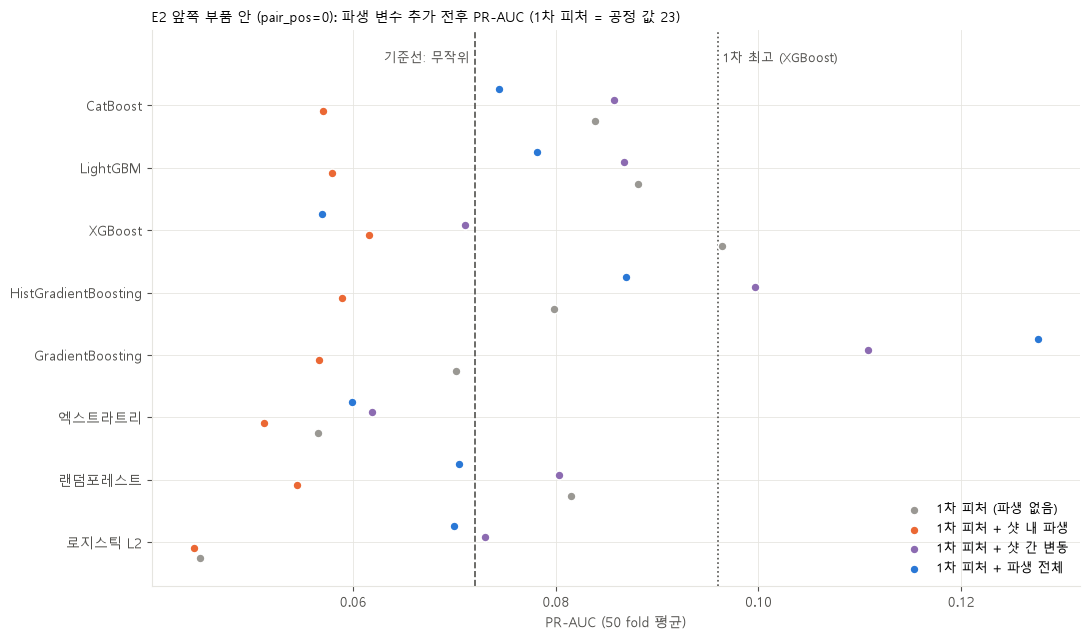

In [10]:
fig, ax = plt.subplots(figsize=(11, 6.5))
fs = [f for f in PLAN[E2_NAME][1] if f.startswith('공정 값 23')]
colors = dict(zip(fs, ['#9a9893', C_SUB, C_ALT, C_MAIN]))
yy = np.arange(len(MODEL_NAMES))
grid = prauc_grid(E2_NAME)
for k, f in enumerate(fs):
    ax.scatter(grid.loc[MODEL_NAMES, f], yy + (k - 1.5) * 0.17, s=40, color=colors[f], edgecolor='white', linewidth=1, zorder=3,
               label=f.replace('공정 값 23', '1차 피처') if f != '공정 값 23' else '1차 피처 (파생 없음)')
first_model, first_feat, first_mean, first_std = ('XGBoost', '공정 값 23', 0.096, 0.061)
vlines = sorted([(base_rows['[기준] 무작위'], '[기준] 무작위'.replace('[기준] ', '기준선: '), '--'), (first_mean, f'1차 최고 ({first_model})', ':')])
for (x, lab, ls), ha in zip(vlines, ['right', 'left']):  # 두 선이 가까워도 라벨이 겹치지 않게 왼쪽 선은 왼쪽에, 오른쪽 선은 오른쪽에
    ax.axvline(x, color=C_INK, linestyle=ls, linewidth=1.2)
    ax.text(x, len(MODEL_NAMES) - 0.35, f' {lab} ' , color=C_INK, fontsize=9, va='bottom', ha=ha)
ax.set_yticks(yy, MODEL_NAMES)
ax.set_ylim(-0.7, len(MODEL_NAMES) + 0.2)
ax.set_xlabel('PR-AUC (50 fold 평균)')
ax.set_title(f'{E2_NAME}: 파생 변수 추가 전후 PR-AUC (1차 피처 = 공정 값 23)', loc='left')
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'derived_prauc.png', dpi=150, bbox_inches='tight')
plt.show()

**E2 결과 읽기**
- **파생 변수의 효과는 모델마다 방향이 다르다.** 파생 전체를 넣었을 때 같은 fold끼리 짝지은 Δ는 −0.040(XGBoost)에서 +0.057(GradientBoosting)까지 흩어진다. 1차 최고였던 XGBoost·LightGBM은 오히려 낮아졌다.
- **샷 내 파생**은 CN7처럼 8개 모델 모두에서 성능을 낮췄다 (Δ −0.001~−0.035).
- 최고는 **GradientBoosting (공정 값 + 파생 전체) 0.128 ± 0.087**이다. GradientBoosting은 1차에서 0.070으로 중위권이었다. 파생 변수를 넣은 24개 조합 중 결과를 보고 고른 최고값이라 낙관적이다. 검사율@재현율0.9는 85%로 무작위(91%)·1차 최고(88%)와 비슷하다.

### 4-3. E1 전체 기간 (참고)

In [11]:
display(prauc_grid(E1_NAME).round(3))
print('기준선:', summary[(summary['eval'] == E1_NAME) & (summary['family'] == '기준선')].set_index('model')['PR-AUC_mean'].round(3).to_dict())
table(E1_NAME, top=10)

features,공정 값 23,공정 값 23 + 파생 전체,공정 값 23 + pair_pos,공정 값 23 + pair_pos + 파생 전체
model,,,,
로지스틱 L2,0.027,0.045,0.049,0.067
랜덤포레스트,0.037,0.033,0.066,0.053
엑스트라트리,0.029,0.031,0.052,0.047
GradientBoosting,0.041,0.067,0.065,0.125
HistGradientBoosting,0.049,0.049,0.063,0.059
XGBoost,0.048,0.030,0.084,0.048
LightGBM,0.049,0.036,0.078,0.059
CatBoost,0.042,0.036,0.071,0.065


기준선: {'[기준] 무작위': 0.047, '[기준] 쌍 순서 규칙': 0.072, '[기준] 샷 순서': 0.025}


,피처,모델,PR-AUC,Recall@10%,Recall@20%,Recall@30%,검사율@재현율0.9,검사율@재현율1
0,공정 값 23 + pair_pos + 파생 전체,GradientBoosting,0.125 ± 0.097,0.308 ± 0.182,0.436 ± 0.201,0.600 ± 0.225,52%,62%
1,공정 값 23 + pair_pos,XGBoost,0.084 ± 0.065,0.256 ± 0.172,0.392 ± 0.171,0.508 ± 0.195,76%,91%
2,공정 값 23 + pair_pos,LightGBM,0.078 ± 0.052,0.252 ± 0.166,0.396 ± 0.178,0.504 ± 0.203,71%,87%
3,-,[기준] 쌍 순서 규칙,0.072 ± 0.047,0.216 ± 0.180,0.400 ± 0.206,0.556 ± 0.226,48%,82%
4,공정 값 23 + pair_pos,CatBoost,0.071 ± 0.041,0.236 ± 0.160,0.404 ± 0.178,0.564 ± 0.192,67%,87%
5,공정 값 23 + 파생 전체,GradientBoosting,0.067 ± 0.042,0.224 ± 0.179,0.356 ± 0.207,0.464 ± 0.204,81%,93%
6,공정 값 23 + pair_pos + 파생 전체,로지스틱 L2,0.067 ± 0.055,0.184 ± 0.156,0.316 ± 0.186,0.488 ± 0.181,79%,92%
7,공정 값 23 + pair_pos,랜덤포레스트,0.066 ± 0.045,0.196 ± 0.148,0.368 ± 0.163,0.492 ± 0.222,75%,91%
8,공정 값 23 + pair_pos + 파생 전체,CatBoost,0.065 ± 0.049,0.180 ± 0.147,0.312 ± 0.167,0.504 ± 0.195,61%,77%
9,공정 값 23 + pair_pos,GradientBoosting,0.065 ± 0.044,0.180 ± 0.147,0.360 ± 0.162,0.508 ± 0.195,61%,85%


- E1에서도 대부분 모델은 파생 변수로 나아지지 않는다. 예외는 GradientBoosting (공정 값 + pair_pos + 파생 전체)으로, PR-AUC 0.125, 검사율@재현율0.9 52%·재현율1 62%다. 쌍 순서 규칙(48%·82%)보다 재현율 1.0에 필요한 검사율이 낮다.
- 하지만 같은 피처로 학습한 나머지 7개 모델은 모두 쌍 순서 규칙 수준 이하다. E2에서도 GradientBoosting만 오른 결과라 한 모델의 우연일 가능성이 크다. E1은 판정에 쓰지 않는다.

### 4-4. 어떤 파생 변수가 쓰였나 (LightGBM 중요도, E2)

1차 피처 + 파생 전체로 학습한 LightGBM의 분할 이득(gain) 중요도를 처음 10개 fold의 학습 데이터에서 평균한다. 설명용이며 판정에는 쓰지 않는다.

구분별 중요도 합: {'샷 간 변동': 0.644, '샷 내 파생': 0.186, '공정 값': 0.17}


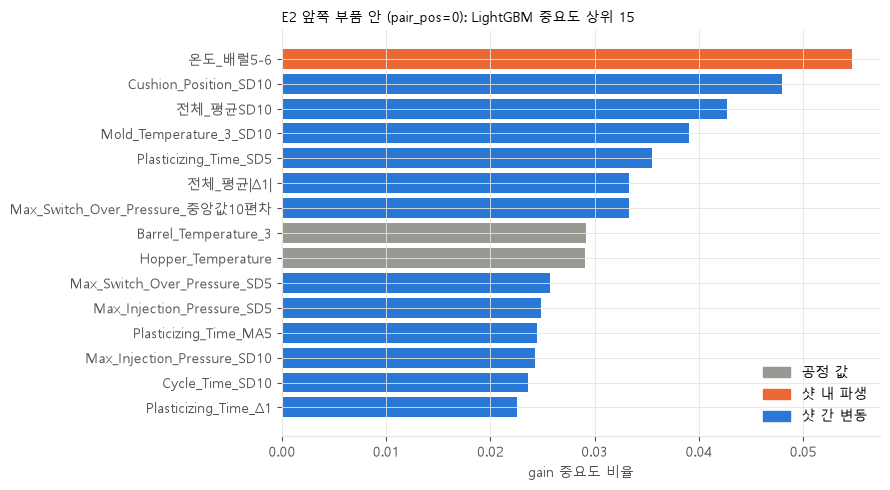

In [12]:
imp_cols = E2_BASES['공정 값 23'] + DERIVED
y2, g2 = e2[TARGET].values, e2['shot_id'].values
X2 = e2[imp_cols].values.astype(float)
gains = []
for tr, te in mz.make_splits(y2, g2)[:10]:
    m = mz._fit(sup['LightGBM'][0], X2[tr], y2[tr], False)
    gains.append(m.booster_.feature_importance('gain'))
imp = pd.Series(np.mean(gains, axis=0), index=imp_cols)
imp = (imp / imp.sum()).sort_values(ascending=False)
grp = pd.Series({c: '공정 값' if c in feats else ('pair_pos' if c == 'pair_pos' else ('샷 내 파생' if c in WITHIN else '샷 간 변동')) for c in imp_cols})
print('구분별 중요도 합:', imp.groupby(grp).sum().sort_values(ascending=False).round(3).to_dict())
top = imp.head(15)
fig, ax = plt.subplots(figsize=(9, 5))
cmap = {'공정 값': '#9a9893', 'pair_pos': C_INK, '샷 내 파생': C_SUB, '샷 간 변동': C_MAIN}
ax.barh(top.index[::-1], top.values[::-1], color=[cmap[grp[c]] for c in top.index[::-1]])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in cmap.items() if k in set(grp)], frameon=False, loc='lower right')
ax.set_xlabel('gain 중요도 비율')
ax.set_title(f'{E2_NAME}: LightGBM 중요도 상위 15', loc='left')
plt.tight_layout()
plt.savefig(FIGS / 'derived_importance.png', dpi=150, bbox_inches='tight')
plt.show()

→ LightGBM은 샷 간 변동에 중요도의 64%를 나눠 주지만, 가장 큰 변수도 5.5%로 **중요도가 고르게 퍼져 있다** (CN7은 상위 2개가 40%). 뚜렷한 신호 없이 여러 변수에 조금씩 분할한 모양이다.
→ 실제로 4-2에서 LightGBM 성능은 파생 변수를 넣으면 0.088 → 0.078로 낮아졌다. 트리 모델은 변수가 많으면 잡음에도 분할 이득을 배분하므로, 중요도가 높다고 해서 정보가 있다는 뜻은 아니다.

### 4-5. 파생 변수는 시간 흐름의 대리 변수인가

3장에서 신호가 가장 강한 파생 변수는 이동평균(MA)이었고, 샷 순서와의 상관(|ρ|)도 컸다. 파생 변수의 이득이 **샷 순서 정보를 다시 표현한 것**인지 직접 확인한다.
- 같은 fold에서 `1차 피처`에 ① 샷 번호(`shot_id`) ② 파생 전체 ③ 둘 다를 붙여 비교한다.
- 해석: ①과 ②가 비슷하고 ③이 ①보다 거의 오르지 않으면, 파생 변수가 더한 정보는 대부분 시간 흐름이다. ③이 ①보다 뚜렷이 오르면 시간 이외의 정보가 있다.
- 샷 번호는 운영 중 알 수 있는 값이지만 **다른 기간에 일반화되지 않는** 정보라 모델 입력 후보로 쓰지 않는다. 진단용이다.

In [13]:
b = E2_BASES['공정 값 23']
PROXY = {'1차 피처': b, '+ 샷 번호': b + ['shot_id'], '+ 파생 전체': b + DERIVED, '+ 샷 번호 + 파생 전체': b + ['shot_id'] + DERIVED}
if RUN:
    y2, g2 = e2[TARGET].values, e2['shot_id'].values
    sp2 = mz.make_splits(y2, g2)
    proxy = pd.concat([mz.evaluate_models(MODELS, e2[c].values.astype(float), y2, g2, sp2)[0].assign(features=k) for k, c in PROXY.items()])
    proxy.to_csv(TABLES / 'derived_time_proxy.csv', index=False, encoding='utf-8-sig')
else:
    proxy = pd.read_csv(TABLES / 'derived_time_proxy.csv')
proxy_tbl = proxy.pivot_table(index='model', columns='features', values='PR-AUC', aggfunc='mean').loc[MODEL_NAMES, list(PROXY)]
proxy_tbl.loc['8종 평균'] = proxy_tbl.mean()
print(f'{E2_NAME} — PR-AUC (50 fold 평균), 1차 피처 = 공정 값 23')
proxy_tbl.round(3)

E2 앞쪽 부품 안 (pair_pos=0) — PR-AUC (50 fold 평균), 1차 피처 = 공정 값 23


features,1차 피처,+ 샷 번호,+ 파생 전체,+ 샷 번호 + 파생 전체
model,,,,
로지스틱 L2,0.045,0.047,0.070,0.073
랜덤포레스트,0.082,0.089,0.070,0.068
엑스트라트리,0.057,0.062,0.060,0.060
GradientBoosting,0.070,0.076,0.128,0.125
HistGradientBoosting,0.080,0.083,0.087,0.085
XGBoost,0.096,0.099,0.057,0.061
LightGBM,0.088,0.084,0.078,0.076
CatBoost,0.084,0.084,0.074,0.077
8종 평균,0.075,0.078,0.078,0.078


→ RG3는 샷 번호를 붙여도 8종 평균이 0.075 → 0.078로 거의 변하지 않는다. 파생 전체(0.078), 둘 다(0.078)도 같다. RG3 불량에는 시간 흐름 신호가 없고(1차 샷 순서 기준선 0.046), 파생 변수가 시간 대리 변수 역할을 할 여지도 없다. CN7과 다른 점이다.

## 5. 추가 기여 검정 (조건부 순열) — 성공 기준 ②

**5-1. 파생 변수의 추가 기여**: 같은 fold에서 `1차 피처` 모델과 `1차 피처 + 파생 전체` 모델의 PR-AUC 차이를 잰다.
- **조건부 순열**: 샷을 연속 10개씩 묶고, 묶음 안에서만 샷끼리 **파생 변수 값**을 뒤섞는다 (공정 값 23개와 `pair_pos`는 그대로, 같은 샷의 두 부품은 같이 이동). 10샷 단위의 시간 흐름은 남기고 "그 10샷 중 어느 샷이 불량인가"에 대한 파생 변수 정보만 지운 기준이다.
- 실제 추가 기여가 이 기준 분포의 상위 5% 밖이어야(p < 0.05) 파생 변수가 **시간 흐름 이상의** 정보를 더한다고 본다. 이동평균처럼 천천히 변하는 변수는 10샷 창 안에서 섞어도 거의 그대로라, 시간 흐름만 담았다면 기준과 차이가 나지 않는다.
- 검정 모델: 사전 고정 LightGBM · 로지스틱 L2 (1차와 같음) + 4장의 2차 최고 모델(다르면 추가, 사후 선택). 계산량 때문에 1차와 같이 2회 반복(10 fold) × 200번.

**5-2. 샷 순서 대비 기여 (1차 `time_increment`와 같은 방식)**: `샷 순서만` 모델과 `샷 순서 + 공정 값 + 파생 전체` 모델을 비교하고, 10샷 창 안에서 공정 값·파생 변수를 함께 섞어 순열 기준을 만든다 (1차와 같이 `pair_pos` 제외).

In [14]:
def cv_ap(model, X, y, splits):
    out = []
    for tr, te in splits:
        m = mz._fit(model, X[tr], y[tr], False)
        out.append(mz.average_precision_score(y[te], mz._score(m, X[te], False)))
    return np.array(out)


def shuffle_in_windows(ev_e, cols, window, rng):
    """샷을 연속 window개씩 묶고 묶음 안에서 샷끼리 cols 값을 뒤섞는다 (같은 샷의 두 부품은 같이 이동)"""
    shot_vals = ev_e.groupby('shot_id')[cols].first()
    sid = shot_vals.index.values
    new = sid.copy()
    for w0 in range(0, len(sid), window):
        idx = np.arange(w0, min(w0 + window, len(sid)))
        new[idx] = sid[rng.permutation(idx)]
    return shot_vals.loc[new].set_axis(sid).loc[ev_e['shot_id']].values


def increment_test(ev_e, fixed, test, model_name, label, n_perm=200, window=10):
    """fixed 모델 대비 fixed + test 모델의 PR-AUC 추가 기여와 조건부 순열 p (test 열만 창 안에서 섞음)"""
    y, g = ev_e[TARGET].values, ev_e['shot_id'].values
    splits = mz.make_splits(y, g)
    model = sup[model_name][0]
    X0 = ev_e[fixed].values.astype(float)
    ap0 = cv_ap(model, X0, y, splits)
    ap1 = cv_ap(model, ev_e[fixed + test].values.astype(float), y, splits)
    obs = ap1[:10].mean() - ap0[:10].mean()

    def one(seed):
        Xp = np.column_stack([X0, shuffle_in_windows(ev_e, test, window, np.random.default_rng(seed))])
        return cv_ap(model, Xp, y, splits[:10]).mean() - ap0[:10].mean()

    null = np.array(Parallel(n_jobs=-1)(delayed(one)(SEED + i) for i in range(n_perm)))
    row = {'검정': label, '모델': model_name, 'PR-AUC 기준 모델': ap0.mean(), 'PR-AUC 추가 모델': ap1.mean(),
           '추가 기여 (50 fold 평균)': ap1.mean() - ap0.mean(), '추가 기여가 양수인 fold 비율': (ap1 > ap0).mean(),
           '추가 기여 (10 fold)': obs, '순열 기준 평균': null.mean(), '순열 기준 95% 상한': np.quantile(null, 0.95),
           '순열 p': (np.sum(null >= obs) + 1) / (n_perm + 1)}
    return row, null


# 4장의 2차 최고 모델 (파생 변수를 넣은 조합 중 E2 PR-AUC 최고)
cand = summary[(summary['eval'] == E2_NAME) & (summary['family'] != '기준선') & summary['features'].str.contains('파생|변동')]
best = cand.sort_values('PR-AUC_mean', ascending=False).iloc[0]
best_base = next(b for b in E2_BASES if best['features'].startswith(b) and best['features'][len(b):] in ADD)
best_add = best['features'][len(best_base):]
print(f"2차 최고: {best['model']} ({best['features']}) PR-AUC {best['PR-AUC_mean']:.3f} ± {best['PR-AUC_std']:.3f}")

TESTS = [('LightGBM', '공정 값 23', ' + 파생 전체'), ('로지스틱 L2', '공정 값 23', ' + 파생 전체')]
if (best['model'], best_base, best_add) not in TESTS:
    TESTS.append((best['model'], best_base, best_add))

if RUN:
    rows, nulls = [], {}
    for m_name, b, a in TESTS:
        t = time.time()
        r, nulls[f'파생 | {m_name} | {b + a}'] = increment_test(e2, E2_BASES[b], ADD[a], m_name, f'5-1 파생 추가 ({b}{a})')
        rows.append(r)
        print(f'5-1 {m_name} {b + a}: {time.time() - t:.0f}s', flush=True)
    for m_name in ['LightGBM', '로지스틱 L2']:
        t = time.time()
        r, nulls[f'시간 | {m_name}'] = increment_test(e2, ['shot_id'], feats + DERIVED, m_name, '5-2 샷 순서 대비 (공정 값 + 파생 전체)')
        rows.append(r)
        print(f'5-2 {m_name}: {time.time() - t:.0f}s', flush=True)
    increment = pd.DataFrame(rows)
    increment.to_csv(TABLES / 'derived_increment.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(nulls).to_csv(TABLES / 'derived_increment_null.csv', index=False, encoding='utf-8-sig')
else:
    increment = pd.read_csv(TABLES / 'derived_increment.csv')
    nulls = pd.read_csv(TABLES / 'derived_increment_null.csv').to_dict('series')
increment.round(3)

2차 최고: GradientBoosting (공정 값 23 + 파생 전체) PR-AUC 0.128 ± 0.087


,검정,모델,PR-AUC 기준 모델,PR-AUC 추가 모델,추가 기여 (50 fold 평균),추가 기여가 양수인 fold 비율,추가 기여 (10 fold),순열 기준 평균,순열 기준 95% 상한,순열 p
0,5-1 파생 추가 (공정 값 23 + 파생 전체),LightGBM,0.088,0.078,-0.010,0.40,-0.025,-0.005,0.045,0.791
1,5-1 파생 추가 (공정 값 23 + 파생 전체),로지스틱 L2,0.045,0.070,0.025,0.86,0.027,0.011,0.042,0.159
2,5-1 파생 추가 (공정 값 23 + 파생 전체),GradientBoosting,0.070,0.128,0.057,0.74,0.056,0.011,0.052,0.035
3,5-2 샷 순서 대비 (공정 값 + 파생 전체),LightGBM,0.057,0.077,0.020,0.68,0.008,0.026,0.076,0.726
4,5-2 샷 순서 대비 (공정 값 + 파생 전체),로지스틱 L2,0.046,0.073,0.027,0.76,0.036,0.022,0.061,0.214


참고 — 1차 샷 순서 대비 공정 값 23개의 추가 기여 (time_increment.csv):


,PR-AUC 샷 순서만,PR-AUC 샷 순서 + 공정 값,추가 기여 (50 fold 평균),순열 p
모델,,,,
로지스틱 L2,0.046,0.047,0.001,0.741
LightGBM,0.057,0.084,0.027,0.348


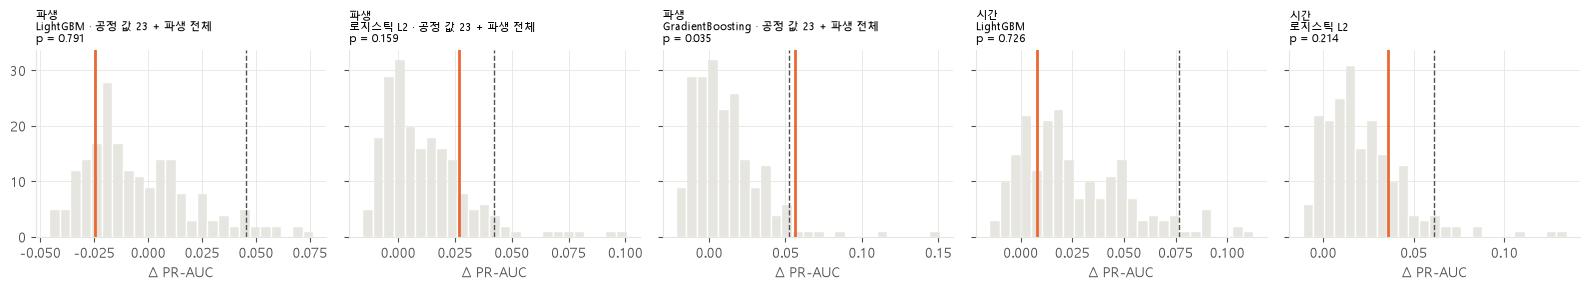

In [15]:
first_inc = pd.read_csv(TABLES / 'time_increment.csv', index_col=0)
print('참고 — 1차 샷 순서 대비 공정 값 23개의 추가 기여 (time_increment.csv):')
display(first_inc[['PR-AUC 샷 순서만', 'PR-AUC 샷 순서 + 공정 값', '추가 기여 (50 fold 평균)', '순열 p']].round(3))

fig, axes = plt.subplots(1, len(nulls), figsize=(3.2 * len(nulls), 3), sharey=True)
for ax, (k, null) in zip(np.atleast_1d(axes), nulls.items()):
    r = increment.iloc[list(nulls).index(k)]
    ax.hist(np.asarray(null), bins=25, color=C_GRID, edgecolor='white')
    ax.axvline(r['추가 기여 (10 fold)'], color=C_SUB, linewidth=2)
    ax.axvline(r['순열 기준 95% 상한'], color=C_INK, linestyle='--', linewidth=1)
    ax.set_title(k.replace(' | ', '\n', 1).replace(' | ', ' · ') + f"\np = {r['순열 p']:.3f}", loc='left', fontsize=8)
    ax.set_xlabel('Δ PR-AUC')
plt.tight_layout()
plt.savefig(FIGS / 'derived_permutation.png', dpi=150, bbox_inches='tight')
plt.show()

- **5-1 파생 추가 (기준 ②)**: 사전에 고정한 두 모델은 유의하지 않다. LightGBM −0.025(p = 0.79), 로지스틱 +0.027(p = 0.16)이다.
- 사후 선택 모델 **GradientBoosting만 +0.056, p = 0.035**다. 하지만 이 모델은 검정 3개 중 결과를 보고 고른 것이라, 다중비교 보정(본페로니 × 3)을 하면 p ≈ 0.11로 유의하지 않다.
- **5-2 샷 순서 대비**: 공정 값 + 파생 전체의 추가 기여도 유의하지 않다 (LightGBM p = 0.73, 로지스틱 p = 0.21). 1차(p = 0.35 / 0.74)와 같은 결론이다.

## 6. 판정 (보고서 표 6)

- **기준 ①**: 2차 최고 모델의 E2 PR-AUC − 비교 대상 ≥ 2차 최고 모델의 fold 간 표준편차 (1차 판정 때 "무작위와의 차이가 fold 간 표준편차 안"이라고 본 것과 같은 방식). 비교 대상 = 기준선 = **무작위** (0.072 ± 0.057, 샷 순서 0.046은 무작위보다 낮음), 1차 최고 = **XGBoost (공정 값)** (0.096 ± 0.061)
  - 보조로, 같은 fold끼리 짝지은 차이(Δ)의 평균이 Δ의 표준편차보다 큰지도 함께 적는다 (짝지은 비교는 fold 난이도 차이가 빠져 더 민감하다).
- **기준 ②**: 5-1에서 2차 최고 모델의 파생 변수 추가 기여 순열 p < 0.05
- 두 기준을 모두 넘어야 **성공**이다.

In [16]:
first_model, first_feat, first_mean, first_std = ('XGBoost', '공정 값 23', 0.096, 0.061)
e2f = folds[folds['eval'] == E2_NAME]
best_folds = e2f[(e2f['model'] == best['model']) & (e2f['features'] == best['features'])].set_index('fold')['PR-AUC']
base_folds = e2f[e2f['model'] == '[기준] 무작위'].set_index('fold')['PR-AUC']
first_folds = e2f[(e2f['model'] == first_model) & (e2f['features'] == first_feat)].set_index('fold')['PR-AUC']
sd = best['PR-AUC_std']
p_best = increment[(increment['모델'] == best['model']) & increment['검정'].str.contains(best['features'], regex=False)]['순열 p'].iloc[0]

rows = []
for name, ref in [('[기준] 무작위'.replace('[기준] ', '기준선: '), base_folds), (f'1차 최고: {first_model} ({first_feat})', first_folds)]:
    d = (best_folds - ref).dropna()
    rows.append({'비교 대상': name, '비교 대상 PR-AUC': ref.mean(), '2차 최고 PR-AUC': best_folds.mean(), '차이': best_folds.mean() - ref.mean(),
                 '2차 최고 fold 표준편차': sd, '① 통과 (차이 ≥ 표준편차)': best_folds.mean() - ref.mean() >= sd,
                 '보조: 짝지은 Δ 평균 / 표준편차': f'{d.mean():+.3f} / {d.std():.3f}', '보조: 개선 fold 비율': (d > 0).mean()})
crit = pd.DataFrame(rows)
display(crit.round(3))
ok1 = bool(crit['① 통과 (차이 ≥ 표준편차)'].all())
ok2 = p_best < 0.05
print(f"기준 ①: {'통과' if ok1 else '미달'} | 기준 ② (5-1 {best['model']} p = {p_best:.3f}): {'통과' if ok2 else '미달'}")
print('판정:', '성공' if ok1 and ok2 else '실패')

table6 = pd.DataFrame([{'제품': 'RG3', '1차 최고 PR-AUC': f'{first_mean:.3f} ± {first_std:.3f} ({first_model})',
                        '2차 최고 모델': f"{best['model']} ({best['features']})",
                        '2차 PR-AUC': f"{best['PR-AUC_mean']:.3f} ± {best['PR-AUC_std']:.3f}",
                        '조건부 순열 p': f'{p_best:.3f}', '판정': '성공' if ok1 and ok2 else '실패'}])
table6.to_csv(TABLES / 'derived_table6.csv', index=False, encoding='utf-8-sig')
table6

,비교 대상,비교 대상 PR-AUC,2차 최고 PR-AUC,차이,2차 최고 fold 표준편차,① 통과 (차이 ≥ 표준편차),보조: 짝지은 Δ 평균 / 표준편차,보조: 개선 fold 비율
0,기준선: 무작위,0.072,0.128,0.055,0.087,False,+0.055 / 0.106,0.70
1,1차 최고: XGBoost (공정 값 23),0.096,0.128,0.031,0.087,False,+0.031 / 0.096,0.64


기준 ①: 미달 | 기준 ② (5-1 GradientBoosting p = 0.035): 통과
판정: 실패


,제품,1차 최고 PR-AUC,2차 최고 모델,2차 PR-AUC,조건부 순열 p,판정
0,RG3,0.096 ± 0.061 (XGBoost),GradientBoosting (공정 값 23 + 파생 전체),0.128 ± 0.087,0.035,실패


→ **2차 판정: 실패**
- 기준 ① 미달: GradientBoosting 0.128은 무작위(0.072)보다 +0.055, 1차 최고(0.096)보다 +0.031 높다. 하지만 두 차이 모두 fold 간 표준편차(0.087)보다 작다. 같은 fold끼리 짝지어 비교해도 Δ 평균이 Δ 표준편차보다 작다.
- 기준 ②는 형식상 통과(p = 0.035)지만, 사후 선택 모델에서만 나온 값이다. 사전 고정 모델(LightGBM·로지스틱)은 유의하지 않고, 보정하면 이 값도 유의하지 않다. 두 기준을 모두 넘어야 성공이므로 판정은 실패다.

## 7. 결론과 5단계 연결

**2차 시도 결과 (보고서 표 6)**

| 제품 | 1차 최고 PR-AUC | 2차 최고 모델 | 2차 PR-AUC | 조건부 순열 p | 판정 |
|---|---|---|---|---|---|
| RG3 | 0.096 ± 0.061 (XGBoost) | GradientBoosting (공정 값 + 파생 전체) | 0.128 ± 0.087 | 0.035 (사후 선택, 보정 시 ≈ 0.11) | **실패** |

1. **파생 변수로도 RG3 불량은 구분되지 않았다.** 단변량 유의 변수는 0개(3장)였다. 8개 모델 중 뚜렷이 개선된 것은 사후 선택된 GradientBoosting 하나이고, 1차 상위 모델(XGBoost·LightGBM)은 오히려 낮아졌다.
2. **샷 내 파생은 모든 모델에서 성능을 낮췄다** (CN7과 같다). 데이터가 표준화된 z값이라 논문의 비율 지표를 만들 수 없었고, 차이는 기존 값의 선형 결합이다.
3. **시간 흐름 신호도 없다** (4-5). CN7처럼 "시간을 다시 맞히는" 효과조차 없다.

→ 1차 결론 **"수집된 공정 값에 불량 정보가 없음"은 파생 변수로도 바뀌지 않았다.** 한 샷의 두 부품은 공정 값이 같다. 그래서 샷 단위로 만든 파생 변수로는 원리적으로 두 부품을 구분할 수 없다는 한계(보고서 제3장)도 그대로다.
→ 성공 기준 ① 미달, ②는 사후 선택 모델에서만 형식상 통과 → **5단계는 "2차 실패" 경로로 간다.**

**5단계 연결 (보고서 제4장)**
- **현재 운영안 유지**: 쌍 순서 규칙(앞쪽 부품 우선, 검사 50%로 불량 92%). 보고서 표 9 그대로다.
- **센서 도입 판단**: RG3 불량의 92%가 한쪽 부품에서 나오는데, 공정 값은 두 부품이 공유해 이 차이를 담지 못한다. 캐비티별 금형 내압 센서(LH/RH 각 1개 이상)가 바로 이 부품별 정보를 줄 수 있다. 도입 여부는 손익분기점 분석으로 판단한다.
- GradientBoosting의 E1 결과(재현율 1.0에 검사 62%)는 한 모델에서만 나온 값이라 운영안에 넣지 않는다. 센서 시범 적용 때 같은 방식으로 다시 확인할 후보로만 남긴다.

**보고서 반영 위치**
- 표 6: 위 표 (`outputs/tables/derived_table6.csv`)
- 제2장 4·5단계: 4-2 표·그림 (`outputs/figures/derived_prauc.png`), 5장 순열검정 (`derived_increment.csv`, `outputs/figures/derived_permutation.png`)
- 제3장 영향요인: 3장 단변량 표 (`derived_univariate.csv`), 4-4 중요도 (`outputs/figures/derived_importance.png`)
- 제4장 "2차 성공 시 예상 검사율": 해당 없음 (2차 실패)
- 표 11 "2차 시도(파생 변수) 코드": `RG31.ipynb` — 결과표 `outputs/tables/derived_*.csv`, 그림 `outputs/figures/derived_*.png`